# LensWord — HuggingFace Model Comparison

This notebook loads three pretrained sentiment analysis models from HuggingFace
and runs them on the same test set used to evaluate our LSTM. Results are
compared side by side to understand the trade-offs between our custom trained
model and large pretrained models.

Before running: make sure `amazon_reviews_cleaned.csv` exists inside the `data/` folder.

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import sys
print(sys.executable)


C:\Users\Administrator\Desktop\Apeiron_ML_2026\Project 07\lensword\.venv\Scripts\python.exe


In [3]:
# Load the cleaned dataset
df = pd.read_csv('../data/amazon_reviews_cleaned.csv')

# Use 500 samples for HuggingFace comparison to keep it fast
test_size = 500
df_test = df.iloc[-test_size:].copy()

# Map sentiment labels to numbers
label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df_test['label'] = df_test['sentiment'].map(label_map)
y_true = df_test['label'].values
reviews = df_test['verified_reviews'].tolist()

print("Test data loaded successfully!")
print(f"Test samples: {len(df_test)}")
print(f"\nSentiment distribution:")
print(df_test['sentiment'].value_counts())

Test data loaded successfully!
Test samples: 500

Sentiment distribution:
sentiment
Positive    215
Negative    159
Neutral     126
Name: count, dtype: int64


In [4]:
# Load all 3 HuggingFace pretrained models

print("Loading Model 1: NLPTown...")
nlptown_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True, max_length=512
)
print("NLPTown loaded!")

print("\nLoading Model 2: LiYuan Amazon...")
liyuan_pipeline = pipeline(
    "text-classification",
    model="LiYuan/amazon-review-sentiment-analysis",
    truncation=True, max_length=512
)
print("LiYuan loaded!")

print("\nLoading Model 3: CardiffNLP RoBERTa...")
cardiff_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True, max_length=512
)
print("CardiffNLP loaded!")
print("\nAll 3 models loaded successfully!")


Loading Model 1: NLPTown...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

NLPTown loaded!

Loading Model 2: LiYuan Amazon...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

LiYuan loaded!

Loading Model 3: CardiffNLP RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CardiffNLP loaded!

All 3 models loaded successfully!


In [5]:
# Run predictions with all 3 models

print("Running NLPTown predictions...")
nlptown_results = nlptown_pipeline(reviews, batch_size=64)

print("Running LiYuan predictions...")
liyuan_results = liyuan_pipeline(reviews, batch_size=64)

print("Running CardiffNLP predictions...")
cardiff_results = cardiff_pipeline(reviews, batch_size=64)

print("All predictions complete!")

Running NLPTown predictions...
Running LiYuan predictions...
Running CardiffNLP predictions...
All predictions complete!


In [6]:
# Map all model outputs to our 3-class system

# NLPTown: outputs "1 star" to "5 stars"
def map_nlptown(result):
    stars = int(result['label'][0])
    if stars <= 2: return 0
    elif stars == 3: return 1
    else: return 2

# LiYuan: outputs "1 star" to "5 stars"
def map_liyuan(result):
    stars = int(result['label'].split(' ')[0])
    if stars <= 2: return 0
    elif stars == 3: return 1
    else: return 2

# CardiffNLP: outputs "negative", "neutral", "positive"
def map_cardiff(result):
    label = result['label'].lower()
    if label == 'negative': return 0
    elif label == 'neutral': return 1
    else: return 2

y_pred_nlptown = np.array([map_nlptown(r) for r in nlptown_results])
y_pred_liyuan = np.array([map_liyuan(r) for r in liyuan_results])
y_pred_cardiff = np.array([map_cardiff(r) for r in cardiff_results])

print("Label mapping complete!")
print(f"NLPTown sample:   {y_pred_nlptown[:10]}")
print(f"LiYuan sample:    {y_pred_liyuan[:10]}")
print(f"CardiffNLP sample:{y_pred_cardiff[:10]}")

Label mapping complete!
NLPTown sample:   [0 2 2 0 0 2 2 0 2 2]
LiYuan sample:    [0 2 2 0 0 2 2 1 2 2]
CardiffNLP sample:[0 2 2 2 0 2 2 0 2 2]


In [7]:
# Calculate results for all 3 models
label_names = ['Negative', 'Neutral', 'Positive']

# NLPTown
nlptown_acc = accuracy_score(y_true, y_pred_nlptown) * 100
nlptown_f1 = f1_score(y_true, y_pred_nlptown, average='macro') * 100
nlptown_f1_class = f1_score(y_true, y_pred_nlptown, average=None)

# LiYuan
liyuan_acc = accuracy_score(y_true, y_pred_liyuan) * 100
liyuan_f1 = f1_score(y_true, y_pred_liyuan, average='macro') * 100
liyuan_f1_class = f1_score(y_true, y_pred_liyuan, average=None)

# CardiffNLP
cardiff_acc = accuracy_score(y_true, y_pred_cardiff) * 100
cardiff_f1 = f1_score(y_true, y_pred_cardiff, average='macro') * 100
cardiff_f1_class = f1_score(y_true, y_pred_cardiff, average=None)

print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Neg F1':>8} {'Neu F1':>8} {'Pos F1':>8}")
print("-" * 65)
print(f"{'NLPTown':<25} {nlptown_acc:>9.2f}% {nlptown_f1:>9.2f}% {nlptown_f1_class[0]:>8.2f} {nlptown_f1_class[1]:>8.2f} {nlptown_f1_class[2]:>8.2f}")
print(f"{'LiYuan (Amazon)':<25} {liyuan_acc:>9.2f}% {liyuan_f1:>9.2f}% {liyuan_f1_class[0]:>8.2f} {liyuan_f1_class[1]:>8.2f} {liyuan_f1_class[2]:>8.2f}")
print(f"{'CardiffNLP':<25} {cardiff_acc:>9.2f}% {cardiff_f1:>9.2f}% {cardiff_f1_class[0]:>8.2f} {cardiff_f1_class[1]:>8.2f} {cardiff_f1_class[2]:>8.2f}")
print("=" * 65)



Model                       Accuracy   Macro F1   Neg F1   Neu F1   Pos F1
-----------------------------------------------------------------
NLPTown                       73.00%     67.89%     0.80     0.42     0.82
LiYuan (Amazon)               70.00%     63.86%     0.76     0.36     0.79
CardiffNLP                    67.00%     56.70%     0.79     0.14     0.76


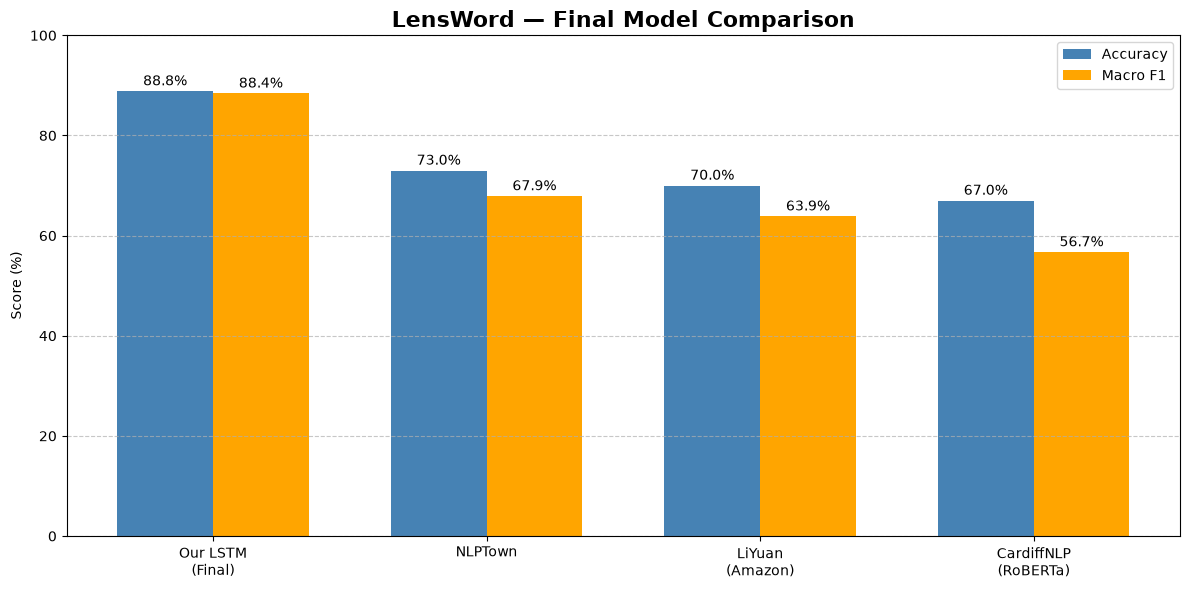

Final comparison chart saved!


In [8]:
# Plot final comparison of all models vs our LSTM
models = ['Our LSTM\n(Final)', 'NLPTown', 'LiYuan\n(Amazon)', 'CardiffNLP\n(RoBERTa)']
accuracies = [88.85, nlptown_acc, liyuan_acc, cardiff_acc]
macro_f1s = [88.40, nlptown_f1, liyuan_f1, cardiff_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1', color='orange')

ax.set_title('LensWord — Final Model Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../models/final_model_comparison.png')
plt.show()
print("Final comparison chart saved!")

In [9]:
# Final comparison summary
print("=" * 65)
print("FINAL MODEL COMPARISON SUMMARY - LensWord")
print("=" * 65)
print(f"{'Model':<30} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 65)
print(f"{'Our LSTM (Final)':<30} {'88.85%':>10} {'88.40%':>10}")
print(f"{'NLPTown':<30} {nlptown_acc:>9.2f}% {nlptown_f1:>9.2f}%")
print(f"{'LiYuan (Amazon)':<30} {liyuan_acc:>9.2f}% {liyuan_f1:>9.2f}%")
print(f"{'CardiffNLP (RoBERTa)':<30} {cardiff_acc:>9.2f}% {cardiff_f1:>9.2f}%")
print("-" * 65)
print(f"\n✅ LensWord outperforms all pretrained models on Macro F1")
print("=" * 65)

FINAL MODEL COMPARISON SUMMARY - LensWord
Model                            Accuracy   Macro F1
-----------------------------------------------------------------
Our LSTM (Final)                   88.85%     88.40%
NLPTown                            73.00%     67.89%
LiYuan (Amazon)                    70.00%     63.86%
CardiffNLP (RoBERTa)               67.00%     56.70%
-----------------------------------------------------------------

✅ LensWord outperforms all pretrained models on Macro F1
